In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os, sys
sys.path.append("/Users/ktd/phd/projects/eo/fixlip")

from PIL import Image
import matplotlib.pyplot as plt
import shapiq 
import src

import os
import torch
import torch.nn.functional as F
import numpy as np
import rioxarray as rxr
import matplotlib.pyplot as plt
from huggingface_hub import hf_hub_download
from plotting_utils import s2_to_rgb, plot_s2, lulc_to_rgb, s1_to_rgb, plot_s1
from terratorch.registry import FULL_MODEL_REGISTRY
from terratorch.tasks.tiled_inference import tiled_inference
from glob import glob

# Select device
if torch.cuda.is_available():
    device = 'cuda'    
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'

In [3]:
inp = torch.zeros((2, 4, 4))
means = torch.tensor([1, 2]).reshape(2, 1, 1).repeat((1, 4, 4))
mask = torch.tensor([[0,0,0,0],[0,1,0,0],[0,0,1,0],[0,0,0,0]]).repeat((2, 1, 1))
inp * mask.logical_not() + means * mask

tensor([[[0., 0., 0., 0.],
         [0., 1., 0., 0.],
         [0., 0., 1., 0.],
         [0., 0., 0., 0.]],

        [[0., 0., 0., 0.],
         [0., 2., 0., 0.],
         [0., 0., 2., 0.],
         [0., 0., 0., 0.]]])

In [4]:
classes = ['unknown', 'water', 'trees', 'flooded vegetation', 'crops', 'built area', 'bare ground', 'snow/ice', 'clouds', 'rangeland']
l = 0
s = 224
img_s2 = 'data/sen1floods11/v1.1/data/flood_events/HandLabeled/S2Hand/Bolivia_129334_S2Hand.tif'
img_s1 = 'data/sen1floods11/v1.1/data/flood_events/HandLabeled/S1Hand/Bolivia_129334_S1Hand.tif'
data_s2 = rxr.open_rasterio(img_s2).values[:, l:l+s, l:l+s]
data_s1 = rxr.open_rasterio(img_s1).values[:, l:l+s, l:l+s]
label = rxr.open_rasterio('data/sen1floods11/v1.1/data/flood_events/HandLabeled/LabelHand/Bolivia_23014_LabelHand.tif').values[:, l:l+s, l:l+s]

input_image_s2 = torch.tensor(data_s2, dtype=torch.float, device=device).unsqueeze(0)
input_image_s1 = torch.tensor(data_s1, dtype=torch.float, device=device).unsqueeze(0)
input_text = torch.tensor([[-20, 15]]).to(device)

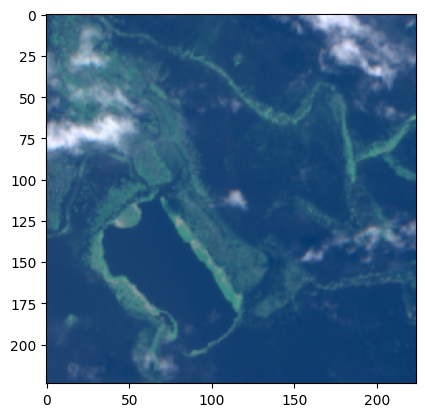

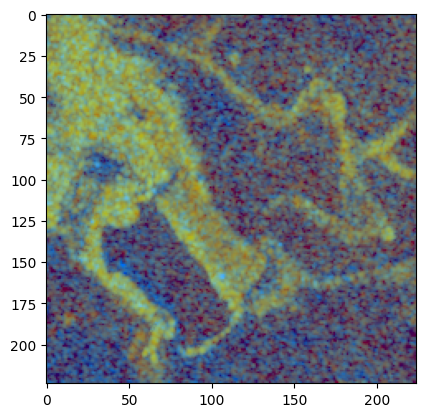

In [5]:
plt.imshow(s2_to_rgb(input_image_s2.detach().cpu().numpy()))
plt.show()
plt.imshow(s1_to_rgb(input_image_s1.detach().cpu().numpy()))

In [6]:
# Define the output from S2L2A, S1GRD, S1RTC, DEM, LULC, and NDVI
output_modalities = ['LULC']

# Build model
model = FULL_MODEL_REGISTRY.build(
    'terramind_v1_small_generate',
    modalities=['S2L1C', 'S1GRD'],
    output_modalities=output_modalities,
    pretrained=True,
    standardize=True,
    timesteps=100,  # Number of diffusion steps
)

model = model.to(device)
lulc = model({'S2L1C': input_image_s2.repeat(4, 1, 1, 1), 'S1GRD': input_image_s1.repeat(4, 1, 1, 1)})['LULC']
# lulc = model({'S2L1C': input_image.repeat(4, 1, 1, 1), 'Coords': input_text.repeat(4, 1)})['LULC']

2026-06-18 10:46:43,197 - INFO - HTTP Request: HEAD https://huggingface.co/ibm-esa-geospatial/TerraMind-1.0-Tokenizer-LULC/resolve/main/TerraMind_Tokenizer_LULC.pt "HTTP/1.1 302 Found"
2026-06-18 10:46:43,709 - INFO - HTTP Request: HEAD https://huggingface.co/ibm-esa-geospatial/TerraMind-1.0-small/resolve/main/TerraMind_v1_small.pt "HTTP/1.1 302 Found"
2026-06-18 10:46:43,709 - WARNING - Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.


array([4.5440048e-03, 1.7519331e-01, 2.8544523e-02, 4.6596977e-01,
       2.0727040e-03, 0.0000000e+00, 0.0000000e+00, 4.9824616e-06,
       9.9549584e-02, 2.2412109e-01], dtype=float32)

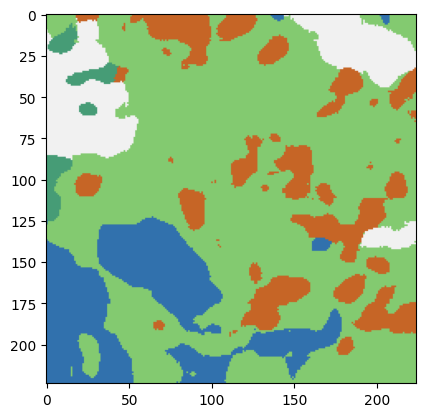

In [7]:
plt.imshow(lulc_to_rgb(lulc.mean(0).detach().cpu().numpy()))
F.one_hot(lulc.argmax(1)).float().mean((0, 1, 2)).cpu().numpy()

In [8]:
plt.ioff()
for fname in glob('data/sen1floods11/v1.1/data/flood_events/HandLabeled/S2Hand/*_S2Hand.tif'):

    img_s2 = fname
    try:
        img_s1 = f'data/sen1floods11/v1.1/data/flood_events/HandLabeled/S1Hand/{fname.split("/")[-1][:-11]}_S1Hand.tif'
        data_s2 = rxr.open_rasterio(img_s2).values[:, l:l+s, l:l+s]
        data_s1 = rxr.open_rasterio(img_s1).values[:, l:l+s, l:l+s]

        input_image_s2 = torch.tensor(data_s2, dtype=torch.float, device=device).unsqueeze(0)
        input_image_s1 = torch.tensor(data_s1, dtype=torch.float, device=device).unsqueeze(0)
        lulc = model({'S2L1C': input_image_s2.repeat(4, 1, 1, 1), 'S1GRD': input_image_s1.repeat(4, 1, 1, 1)})['LULC']
        cl_parts = F.one_hot(lulc.argmax(1)).float().mean((0, 1, 2)).cpu().numpy()
    except:
        continue

    for i, cl in enumerate(cl_parts):
        if i == 0 or cl < 0.1 or cl > 0.5:
            continue

        try:
            game = src.game_terramind.VisionLanguageGame(
                model=model,
                inputs={'S2L1C': input_image_s2, 'S1GRD': input_image_s1}, 
                modalities={'S2L1C': 'image', 'S1GRD': 'image'}, 
                mask_names={'S2L1C': 'untok_sen2l1c@224', 'S1GRD': 'untok_sen1grd@224'},
                batch_size=16,
                cl=i,
                grid_step=7,
            )

            fixlip = src.fixlip.FIxLIP(
                n_players_modalities=game.n_players_image | game.n_players_text, 
                max_order=2,
                p=0.5, # weight
                mode="banzhaf",
                random_state=0
            )

            src.utils.set_seed(0)
            interaction_values = fixlip.approximate_crossmodal(game, budget=2**13)
        except:
            continue

        n_players_image = game.n_players_image
        n_players_text = game.n_players_text

        # fig, axs = plt.subplots(1, 2, figsize=(12, 4))
        fig, axs = plt.subplots(2, 3, figsize=(12, 8))
        axs = axs.flatten()


        orig = {'S2L1C': torch.tensor(data_s2, dtype=torch.float, device=device).unsqueeze(0), 'S1GRD': torch.tensor(data_s1, dtype=torch.float, device=device).unsqueeze(0)}
        # orig = {'S2L1C': torch.tensor(data_s2, dtype=torch.float, device=device).unsqueeze(0), 'Coords': input_text}
        tokenized = model.forward_tokenizer(orig)
        out = model.forward_tokenized(tokenized, orig)

        src.plot.plot_image_and_text_together(
            img={'S2L1C': s2_to_rgb(input_image_s2), 'S1GRD': s1_to_rgb(input_image_s1)},
            # text=tokenized['coords']['tensor'].cpu().detach().numpy()[0].astype(str)[:-1],
            # text=input_text.cpu().detach().numpy()[0].astype(str),
            text=[],
            image_players=n_players_image,
            iv=interaction_values,
            plot_interactions=True,
            top_k=50,
            normalize_jointly=True,
            figsize=(7, 7),
            fontsize=12,
            margin=0.3,
            color_text=True,
            plot_heatmap=True,
            show=True,
            max_value=None,
            axes=axs[:2]
        )

        sample_name = img_s2.split("/")[-1][:-4]

        fig.suptitle(f"File: {sample_name}, Class: {classes[i]}")

        axs[2].text(0, 0, str(interaction_values), wrap=True)
        axs[2].axis('off')

        plot_s2(data_s2, ax=axs[3])
        axs[3].set_title("Original image S2")

        plot_s1(data_s1, ax=axs[4])
        axs[4].set_title("Original image S1")
        
        axs[5].imshow(lulc_to_rgb(lulc.mean(0).detach().cpu().numpy()))
        axs[5].axis('off')
        axs[5].set_title("Original segmentation")

        plt.tight_layout()
        plt.savefig(f'figures/attributions_multiimage/attribution_{sample_name}_class_{i}')


# game.empty_value, game.full_value

100%|██████████| 1/1 [00:05<00:00,  5.49s/it]
/Users/ktd/phd/projects/eo/fixlip/src/utils.py:378: UserWarning: Index `FWBII` is not a valid interaction index. Valid indices are: SII, BII, CHII, Co-Moebius, SGV, BGV, CHGV, IGV, EGV, k-SII, STII, FSII, kADD-SHAP, FBII, SV, BV, JointSV, Moebius, ELC.
  return InteractionValues(
/opt/anaconda3/envs/terratorch2/lib/python3.11/site-packages/shapiq/interaction_values.py:715: UserWarning: Index `FWBII` is not a valid interaction index. Valid indices are: SII, BII, CHII, Co-Moebius, SGV, BGV, CHGV, IGV, EGV, k-SII, STII, FSII, kADD-SHAP, FBII, SV, BV, JointSV, Moebius, ELC.
  return InteractionValues(
/Users/ktd/phd/projects/eo/fixlip/src/plot.py:699: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.05)
/var/folders/8b/6b2t7b315p311388qfgc6jlw0000gn/T/ipykernel_23358/2506396197.py:95: UserWarning: This figure includes Axes that are not compatible with tight

In [ ]:
plt.ioff()
for fname in glob('data/sen1floods11/v1.1/data/flood_events/HandLabeled/S2Hand/*_S2Hand.tif'):

    img_s2 = fname
    try:
        img_s1 = f'data/sen1floods11/v1.1/data/flood_events/HandLabeled/S1Hand/{fname.split("/")[-1][:-11]}_S1Hand.tif'
        data_s2 = rxr.open_rasterio(img_s2).values[:, l:l+s, l:l+s]
        data_s1 = rxr.open_rasterio(img_s1).values[:, l:l+s, l:l+s]

        input_image_s2 = torch.tensor(data_s2, dtype=torch.float, device=device).unsqueeze(0)
        input_image_s1 = torch.tensor(data_s1, dtype=torch.float, device=device).unsqueeze(0)
        lulc = model({'S2L1C': input_image_s2.repeat(4, 1, 1, 1), 'S1GRD': input_image_s1.repeat(4, 1, 1, 1)})['LULC']
        cl_parts = F.one_hot(lulc.argmax(1)).float().mean((0, 1, 2)).cpu().numpy()
    except:
        continue

    for i, cl in enumerate(cl_parts):
        if i == 0 or cl < 0.1 or cl > 0.5:
            continue

        try:
            game = src.game_terramind.VisionLanguageGame(
                model=model,
                inputs={'S2L1C': input_image_s2, 'S1GRD': input_image_s1}, 
                modalities={'S2L1C': 'image', 'S1GRD': 'image'}, 
                mask_names={'S2L1C': 'untok_sen2l1c@224', 'S1GRD': 'untok_sen1grd@224'},
                batch_size=16,
                cl=i,
                grid_step=4,
            )

            fixlip = src.fixlip.FIxLIP(
                n_players_modalities=game.n_players_image | game.n_players_text, 
                max_order=2,
                p=0.5, # weight
                mode="banzhaf",
                random_state=0
            )

            src.utils.set_seed(0)
            interaction_values = fixlip.approximate_crossmodal(game, budget=2**15)
        except:
            continue

        n_players_image = game.n_players_image
        n_players_text = game.n_players_text

        # fig, axs = plt.subplots(1, 2, figsize=(12, 4))
        fig, axs = plt.subplots(2, 3, figsize=(12, 8))
        axs = axs.flatten()


        orig = {'S2L1C': torch.tensor(data_s2, dtype=torch.float, device=device).unsqueeze(0), 'S1GRD': torch.tensor(data_s1, dtype=torch.float, device=device).unsqueeze(0)}
        # orig = {'S2L1C': torch.tensor(data_s2, dtype=torch.float, device=device).unsqueeze(0), 'Coords': input_text}
        tokenized = model.forward_tokenizer(orig)
        out = model.forward_tokenized(tokenized, orig)

        src.plot.plot_image_and_text_together(
            img={'S2L1C': s2_to_rgb(input_image_s2), 'S1GRD': s1_to_rgb(input_image_s1)},
            # text=tokenized['coords']['tensor'].cpu().detach().numpy()[0].astype(str)[:-1],
            # text=input_text.cpu().detach().numpy()[0].astype(str),
            text=[],
            image_players=n_players_image,
            iv=interaction_values,
            plot_interactions=True,
            top_k=50,
            normalize_jointly=True,
            figsize=(7, 7),
            fontsize=12,
            margin=0.3,
            color_text=True,
            plot_heatmap=True,
            show=True,
            max_value=None,
            axes=axs[:2]
        )

        sample_name = img_s2.split("/")[-1][:-4]

        fig.suptitle(f"File: {sample_name}, Class: {classes[i]}")

        axs[2].text(0, 0, str(interaction_values), wrap=True)
        axs[2].axis('off')

        plot_s2(data_s2, ax=axs[3])
        axs[3].set_title("Original image S2")

        plot_s1(data_s1, ax=axs[4])
        axs[4].set_title("Original image S1")
        
        axs[5].imshow(lulc_to_rgb(lulc.mean(0).detach().cpu().numpy()))
        axs[5].axis('off')
        axs[5].set_title("Original segmentation")

        plt.tight_layout()
        plt.savefig(f'figures/attributions_multiimage/attribution_dense_{sample_name}_class_{i}')


# game.empty_value, game.full_value

100%|██████████| 144/144 [10:05<00:00,  4.21s/it]
/Users/ktd/phd/projects/eo/fixlip/src/utils.py:378: UserWarning: Index `FWBII` is not a valid interaction index. Valid indices are: SII, BII, CHII, Co-Moebius, SGV, BGV, CHGV, IGV, EGV, k-SII, STII, FSII, kADD-SHAP, FBII, SV, BV, JointSV, Moebius, ELC.
  return InteractionValues(
/opt/anaconda3/envs/terratorch2/lib/python3.11/site-packages/shapiq/interaction_values.py:715: UserWarning: Index `FWBII` is not a valid interaction index. Valid indices are: SII, BII, CHII, Co-Moebius, SGV, BGV, CHGV, IGV, EGV, k-SII, STII, FSII, kADD-SHAP, FBII, SV, BV, JointSV, Moebius, ELC.
  return InteractionValues(
/Users/ktd/phd/projects/eo/fixlip/src/plot.py:699: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.05)
/var/folders/8b/6b2t7b315p311388qfgc6jlw0000gn/T/ipykernel_3091/3042087965.py:95: UserWarning: This figure includes Axes that are not compatible with ti

In [25]:
cl = 1
game = src.game_terramind.VisionLanguageGame(
    model=model,
    inputs={'S2L1C': input_image_s2, 'S1GRD': input_image_s1}, 
    modalities={'S2L1C': 'image', 'S1GRD': 'image'}, 
    mask_names={'S2L1C': 'untok_sen2l1c@224', 'S1GRD': 'untok_sen1grd@224'},
    batch_size=16,
    cl=cl,
    grid_step=4,
)

fixlip = src.fixlip.FIxLIP(
    n_players_modalities=game.n_players_image | game.n_players_text, 
    max_order=2,
    p=0.5, # weight
    mode="banzhaf",
    random_state=0
)

# fixlip = src.fixlip.FIxLIP(
#     n_players_image=n_players_image,
#     n_players_text=n_players_text, 
#     max_order=2,
#     p=0.5, # weight
#     mode="banzhaf",
#     random_state=0
# )

src.utils.set_seed(0)
interaction_values = fixlip.approximate_crossmodal(game, budget=2**15)
print(interaction_values)

100%|██████████| 144/144 [10:22<00:00,  4.33s/it]

InteractionValues(
    index=FWBII, max_order=2, min_order=0, estimated=True, estimation_budget=33124,
    n_players=32, baseline_value=8.259759699834193,
    Top 10 interactions:
        (): 8.259759699834193
        (31,): 1.638102322599709
        (30,): 1.451749391958828
        (29,): 1.4461187141251253
        (24,): 1.182221785432106
        (0,): -1.3144714494572654
        (2,): -1.345263515453739
        (6,): -1.4459815404163865
        (10,): -1.6215296317262957
        (26,): -1.8078413244846103
)


/Users/ktd/phd/projects/eo/fixlip/src/utils.py:378: UserWarning: Index `FWBII` is not a valid interaction index. Valid indices are: SII, BII, CHII, Co-Moebius, SGV, BGV, CHGV, IGV, EGV, k-SII, STII, FSII, kADD-SHAP, FBII, SV, BV, JointSV, Moebius, ELC.
  return InteractionValues(
/opt/anaconda3/envs/terratorch2/lib/python3.11/site-packages/shapiq/interaction_values.py:715: UserWarning: Index `FWBII` is not a valid interaction index. Valid indices are: SII, BII, CHII, Co-Moebius, SGV, BGV, CHGV, IGV, EGV, k-SII, STII, FSII, kADD-SHAP, FBII, SV, BV, JointSV, Moebius, ELC.
  return InteractionValues(
/Users/ktd/phd/projects/eo/fixlip/src/plot.py:699: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.05)
/var/folders/8b/6b2t7b315p311388qfgc6jlw0000gn/T/ipykernel_3091/3258709167.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.t

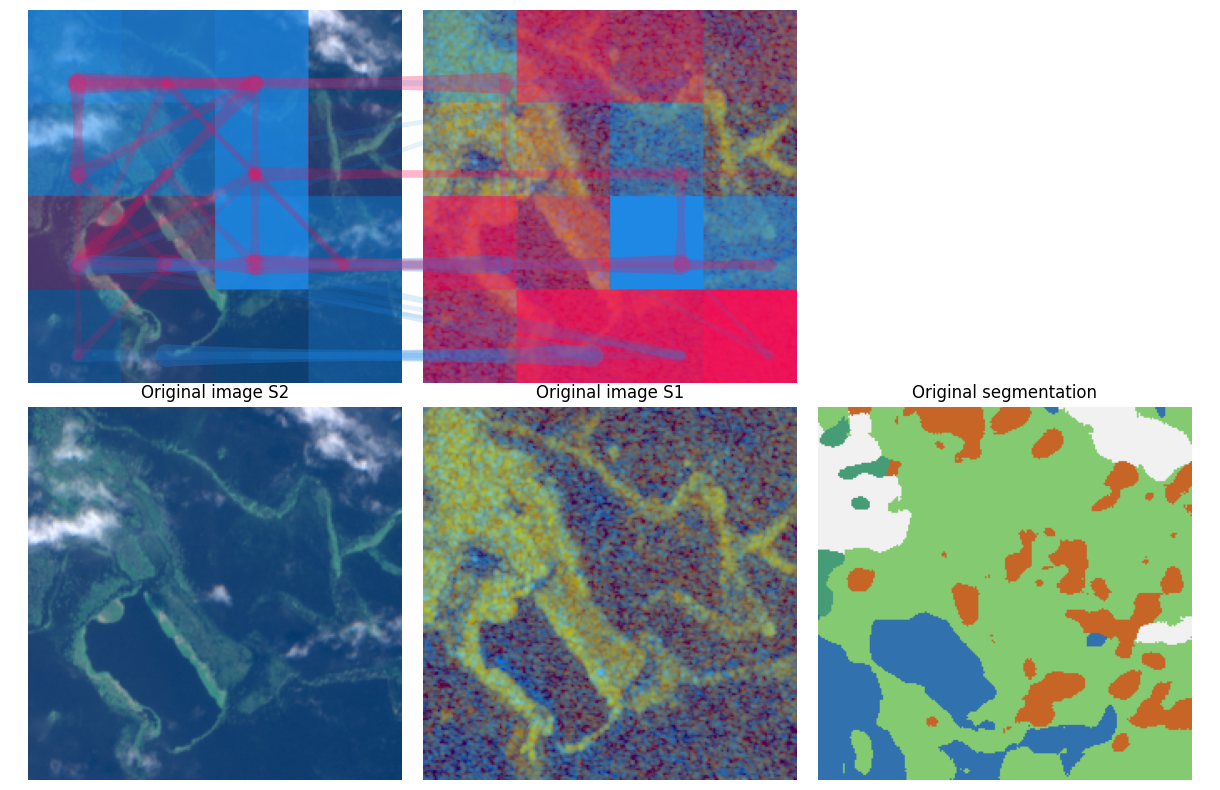

In [26]:
n_players_image = game.n_players_image
n_players_text = game.n_players_text
# fig, axs = plt.subplots(1, 2, figsize=(12, 4))
fig = plt.figure(figsize=(12, 8))
ax1 = plt.subplot(2,3,1)
ax2 = plt.subplot(2,3,2)
ax3 = plt.subplot(2,3,4)
ax4 = plt.subplot(2,3,5)
ax5 = plt.subplot(2,3,6)
axs = [ax1, ax2, ax3, ax4, ax5]


orig = {'S2L1C': torch.tensor(data_s2, dtype=torch.float, device=device).unsqueeze(0), 'S1GRD': torch.tensor(data_s1, dtype=torch.float, device=device).unsqueeze(0)}
# orig = {'S2L1C': torch.tensor(data_s2, dtype=torch.float, device=device).unsqueeze(0), 'Coords': input_text}
tokenized = model.forward_tokenizer(orig)
out = model.forward_tokenized(tokenized, orig)

src.plot.plot_image_and_text_together(
    img={'S2L1C': s2_to_rgb(input_image_s2), 'S1GRD': s1_to_rgb(input_image_s1)},
    # text=tokenized['coords']['tensor'].cpu().detach().numpy()[0].astype(str)[:-1],
    # text=input_text.cpu().detach().numpy()[0].astype(str),
    text=[],
    image_players=n_players_image,
    iv=interaction_values,
    plot_interactions=True,
    top_k=50,
    normalize_jointly=True,
    figsize=(7, 7),
    fontsize=12,
    margin=0.3,
    color_text=True,
    plot_heatmap=True,
    show=True,
    max_value=None,
    axes=axs[:2]
)
# fig.suptitle(f"Attributions class {classes[cl]}")
# plt.show()
# fig, axs = plt.subplots(1, 3, figsize=(12, 4))

# out['S2L2A'].shape
# out = model(orig)
axs[4].imshow(lulc_to_rgb(lulc.mean(0).detach().cpu().numpy()))
axs[4].axis('off')
axs[4].set_title("Original segmentation")

plot_s2(data_s2, ax=axs[2])
axs[2].set_title("Original image S2")
# plt.savefig(f'figures/attributions/attribution_{img_s2.split("/")[-1][:-4]}_class_{cl}')

plot_s1(data_s1, ax=axs[3])
axs[3].set_title("Original image S1")
# plt.savefig(f'figures/attributions_multiimage/attribution_{img_s2.split("/")[-1][:-4]}_class_{cl}')
plt.tight_layout()
plt.show()

In [ ]:
interaction_values.interactions

{(): 4.069589084020248,
 (0,): 2.1752335170431745,
 (1,): 0.6750427331906632,
 (2,): 1.7294344928137466,
 (3,): -0.3148236389511926,
 (4,): -0.36894975776201683,
 (5,): 1.7569370014504304,
 (6,): 1.060322654527842,
 (7,): 0.870306070621704,
 (8,): -0.04409976420308694,
 (9,): 0.33389206090345047,
 (10,): -0.23206673867854266,
 (11,): -0.21382082974202482,
 (12,): -0.44246996552607454,
 (13,): -0.9367445847513323,
 (14,): -0.9394674511531483,
 (15,): -0.4990168165247962,
 (16,): -0.794991812875746,
 (17,): -0.33654799961902815,
 (0, 1): -0.6343632722587699,
 (0, 2): -0.6898890673300171,
 (0, 3): 0.16980944377152937,
 (0, 4): 0.05956789324631867,
 (0, 5): -0.6030055276663395,
 (0, 6): -0.5130128259592217,
 (0, 7): -0.5203044878917121,
 (0, 8): -0.08069729486744759,
 (0, 9): -0.08491874778396982,
 (0, 10): 0.10752550631953825,
 (0, 11): -0.05307236884906757,
 (0, 12): -0.12581441349600095,
 (0, 13): 0.26350572966588526,
 (0, 14): -0.05707617587254388,
 (0, 15): 0.0056932009478723195,
 (0,

In [ ]:
inter = {}
c = 48
for k, v in interaction_values.interaction_lookup.items():
    if len(k) < 2:
        continue
    if (k[0] > c and k[1] < c) or (k[0] < c and k[1] > c):
        inter[k] = interaction_values.values[v]

In [ ]:
{k: v for k, v in sorted(inter.items(), key=lambda item: item[1])}

{}

In [ ]:
plt.imshow(lulc_to_rgb(game.outs[0][6]))

AttributeError: 'VisionLanguageGame' object has no attribute 'outs'

In [ ]:
tokenized['coords']['tensor'].cpu().detach().numpy()[0].astype(str)

array(['4564', '5645', '3'], dtype='<U21')

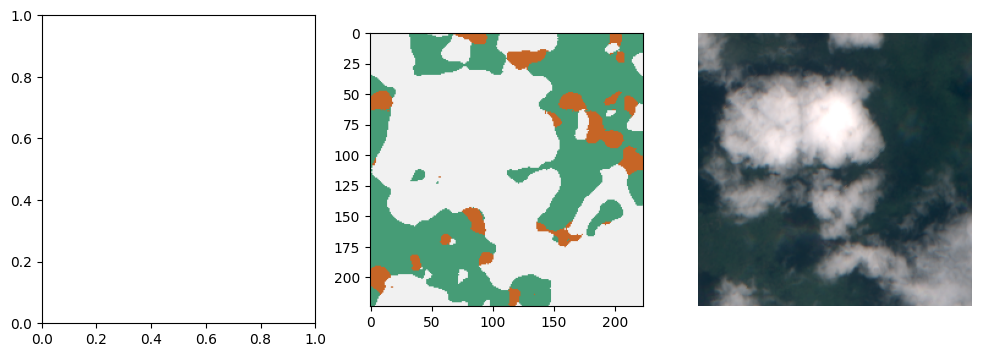

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(12, 4))


out = model(orig)
orig = {'S2L1C': input_image, 'Coords': input_text}
tokenized = model.forward_tokenizer(orig)
out = model.forward_tokenized(tokenized, orig)
# out = model(orig)
axs[1].imshow(lulc_to_rgb(out['LULC'].detach().cpu()))
plot_s2(data, ax=axs[2])
plt.show()

tensor([[ True,  True,  True,  True,  True,  True, False, False, False, False,
         False, False, False, False,  True,  True,  True,  True,  True,  True,
         False, False, False, False, False, False, False, False,  True,  True,
         False, False,  True,  True, False, False,  True,  True, False, False,
         False, False,  True,  True, False, False,  True,  True, False, False,
          True,  True, False, False, False, False, False, False, False, False,
         False, False,  True,  True, False, False, False, False, False, False,
         False, False, False, False, False, False,  True,  True, False, False,
         False, False, False, False, False, False,  True,  True, False, False,
         False, False, False, False,  True,  True,  True,  True, False, False,
          True,  True, False, False, False, False, False, False,  True,  True,
          True,  True, False, False, False, False,  True,  True, False, False,
         False, False,  True,  True,  True,  True, F

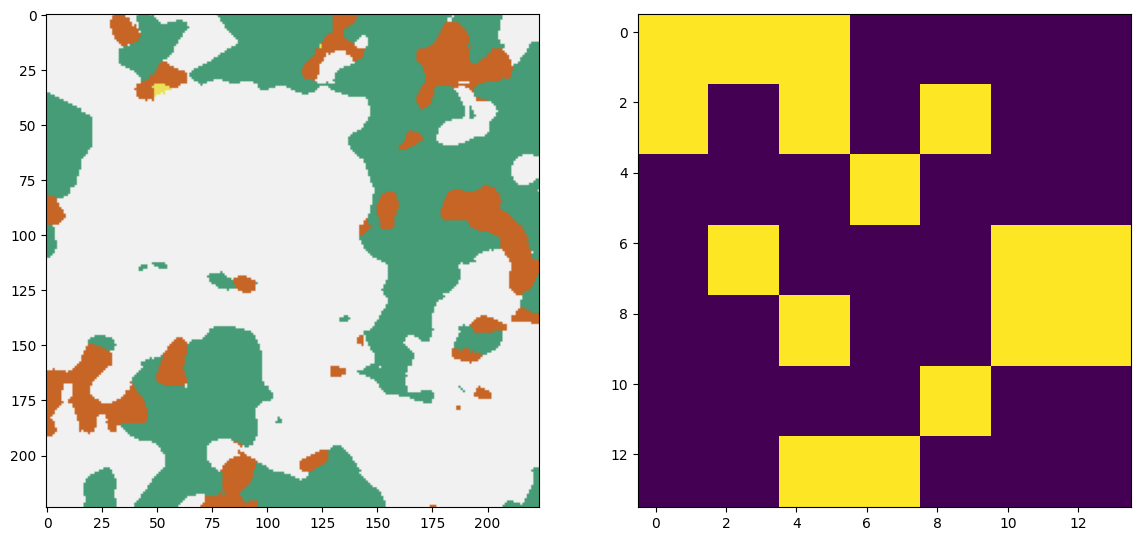

In [ ]:
from copy import deepcopy
# input_image[:, :, :100, :100] = 0
orig = {'S2L1C': input_image_s2, 'S1GRD': input_image_s1}

# mask = torch.ones(1, 196, dtype=torch.bool, device=device)
mask = game.masks[0]['untok_sen2l1c@224'][[0]]
mask_coords = torch.ones(1, 2, dtype=torch.bool, device=device)
masks = {'untok_sen2l1c@224': mask, 'coords': mask_coords}
# mask[0, 20:180] = False
model.forward_tokenizer(deepcopy(orig))
fig, axs = plt.subplots(1, 2, figsize=(14, 7))
axs[0].imshow(lulc_to_rgb(model.forward(orig, mask=masks)['LULC'].cpu().detach().numpy()))
axs[1].imshow(mask.cpu().numpy().reshape(14, 14))
print(mask)

In [ ]:
len(game.outs)

64

In [ ]:
mask.logical_not()

tensor([[False, False, False, False, False, False,  True,  True,  True,  True,
          True,  True,  True,  True, False, False, False, False, False, False,
          True,  True,  True,  True,  True,  True,  True,  True, False, False,
          True,  True, False, False,  True,  True, False, False,  True,  True,
          True,  True, False, False,  True,  True, False, False,  True,  True,
         False, False,  True,  True,  True,  True,  True,  True,  True,  True,
          True,  True, False, False,  True,  True,  True,  True,  True,  True,
          True,  True,  True,  True,  True,  True, False, False,  True,  True,
          True,  True,  True,  True,  True,  True, False, False,  True,  True,
          True,  True,  True,  True, False, False, False, False,  True,  True,
         False, False,  True,  True,  True,  True,  True,  True, False, False,
         False, False,  True,  True,  True,  True, False, False,  True,  True,
          True,  True, False, False, False, False,  

In [ ]:
(out['LULC'].argmax(axis=1) == ).to(torch.float).mean((1, 2))

SyntaxError: invalid syntax (3708914106.py, line 1)

In [ ]:
game.masks[0]['untok_sen2l1c@224'][0]

tensor([ True,  True,  True,  True,  True,  True, False, False, False, False,
         True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
        False, False, False, False,  True,  True,  True,  True, False, False,
         True,  True, False, False, False, False,  True,  True,  True,  True,
        False, False, False, False,  True,  True, False, False, False, False,
         True,  True,  True,  True, False, False, False, False, False, False,
        False, False,  True,  True,  True,  True, False, False,  True,  True,
        False, False, False, False, False, False,  True,  True,  True,  True,
        False, False,  True,  True,  True,  True,  True,  True, False, False,
         True,  True,  True,  True,  True,  True, False, False,  True,  True,
         True,  True, False, False,  True,  True,  True,  True,  True,  True,
        False, False, False, False,  True,  True,  True,  True, False, False,
        False, False, False, False,  True,  True, False, False, 

In [ ]:
fixlip.sampler_image.coalitions_matrix.shape

(4, 49)

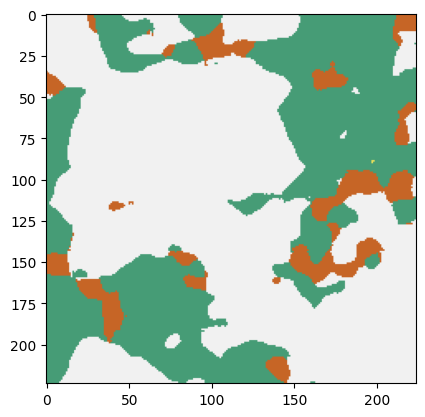

In [ ]:
out = model({'S2L1C': input_image, 'Coords': input_text})
lulc = out['LULC']
plt.imshow(lulc_to_rgb(lulc.cpu().detach().numpy()))

In [ ]:
lulc.softmax(1)[:, 8].mean()

tensor(0.5742, device='mps:0', grad_fn=<MeanBackward0>)

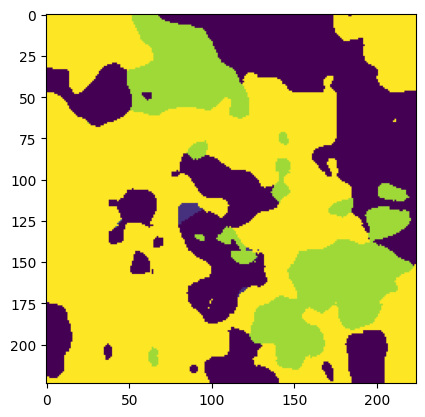

In [ ]:
lulc = lulc.argmax(1)
lulc[lulc == 1] = 2
plt.imshow(lulc.cpu().detach().numpy()[0, :, :])

In [ ]:
model = FULL_MODEL_REGISTRY.build(
    'terramind_v1_tiny_generate',
    modalities=['S2L1C'],
    output_modalities=['S2L1C'],
    pretrained=True,
    standardize=True,
    timesteps=10,  # Number of diffusion steps
)

model = model.to(device)


tensor([[False, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False, False,
          True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
          True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
          True,  True,  True,  True,  True,  True,  

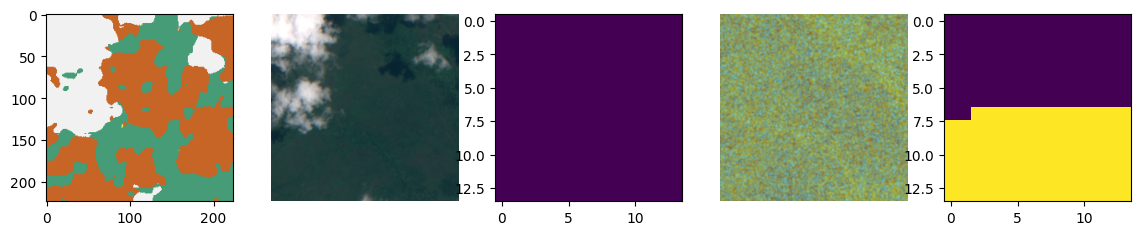

In [ ]:
from copy import deepcopy
# input_image[:, :, :100, :100] = 0
orig = {'S2L1C': input_image_s2, 'S1GRD': input_image_s1}

mask_s2 = torch.ones(1, 196, dtype=torch.bool, device=device)
mask_s1 = torch.ones(1, 196, dtype=torch.bool, device=device)
masks = {'untok_sen2l1c@224': mask_s2, 'untok_sen1grd@224': mask_s1}
mask_s1[0, 0:100] = False
# model.forward_tokenizer(deepcopy(orig))
fig, axs = plt.subplots(1, 5, figsize=(14, 7))
axs[0].imshow(lulc_to_rgb(model.forward(orig, mask=masks)['LULC'].cpu().detach().numpy()))
plot_s2(data_s2, ax=axs[1])
axs[2].imshow(mask_s2.cpu().numpy().reshape(14, 14))
plot_s1(data_s1, ax=axs[3])
axs[4].imshow(mask_s1.cpu().numpy().reshape(14, 14))
print(mask_s1)

In [ ]:
help(model)

Help on TerraMindGeneration in module terratorch.models.backbones.terramind.model.terramind_generation object:

class TerraMindGeneration(torch.nn.modules.module.Module)
 |  TerraMindGeneration(img_size: int = 224, modalities: list[str] | dict[str, int | torch.nn.modules.module.Module] | None = None, output_modalities: list[str] | None = None, decoding_steps: list[int] | int = 1, temps: list[float] | float = 1.0, top_p: float = 0.8, top_k: int = 0, timesteps: int = 50, patch_size: int = 16, dim: int = 768, encoder_depth: int = 12, decoder_depth: int = 12, num_heads: int = 12, mlp_ratio: float = 4.0, qkv_bias: bool = True, proj_bias: bool = True, mlp_bias: bool = True, num_register_tokens: int = 0, act_layer: torch.nn.modules.module.Module = <class 'torch.nn.modules.activation.GELU'>, norm_layer: functools.partial | torch.nn.modules.module.Module = functools.partial(<class 'terratorch.models.backbones.terramind.model.tm_utils.LayerNorm'>, eps=1e-06), gated_mlp: bool = False, qk_norm: bo